# Unsupervised Learning: Clustering and Dimensionality Reduction Using the Iris Dataset

## Introduction

This project demonstrates the application of unsupervised machine learning techniques using the Iris dataset. The objective is to discover natural groupings within the data without using predefined class labels. The project includes data preprocessing, clustering using K-Means and Hierarchical Clustering, dimensionality reduction using Principal Component Analysis (PCA), model evaluation using the Silhouette Score, and recommendations for deployment and model monitoring.

In [1]:
# Import required libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering

from sklearn.metrics import silhouette_score

from sklearn.decomposition import PCA

from scipy.cluster.hierarchy import dendrogram, linkage

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


## Dataset Selection

The Iris dataset is one of the most widely used datasets for clustering and dimensionality reduction. It contains measurements of iris flowers, including sepal length, sepal width, petal length, and petal width. Although the dataset includes species labels, these labels will not be used during clustering because this is an unsupervised learning task.

## Load the Dataset

The Iris dataset is loaded directly from the Scikit-learn library. Since this is an unsupervised learning task, only the feature variables will be used during clustering. The species labels are retained only for visualization and comparison purposes.

In [2]:
# Load the Iris dataset

iris = load_iris()

# Create a DataFrame

df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

# Add species names (for visualization only)

df["species"] = iris.target

# Display the first five rows

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


## Data Exploration and Preprocessing

Before applying clustering algorithms, the dataset is explored to understand its structure and quality. This includes checking the shape of the dataset, data types, missing values, duplicate records, and descriptive statistics.

In [3]:
# Dataset information

print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Dataset Shape: (150, 5)

Column Names:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)', 'species']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [4]:
# Summary statistics

df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [5]:
# Check for missing values

df.isnull().sum()

,0
sepal length (cm),0
sepal width (cm),0
petal length (cm),0
petal width (cm),0
species,0


In [6]:
# Check for duplicate rows

print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 1


In [7]:
# Remove duplicates if any

df = df.drop_duplicates()

print("New Dataset Shape:", df.shape)

New Dataset Shape: (149, 5)


## Feature Scaling

Feature scaling is performed to ensure that all variables contribute equally to the clustering process. Standardization transforms the features to have a mean of zero and a standard deviation of one.

In [8]:
# Standardize the features

X = df.drop("species", axis=1)

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Feature scaling completed successfully.")

Feature scaling completed successfully.


## K-Means Clustering

K-Means clustering groups similar observations into clusters based on their feature values. The Elbow Method is used to determine the optimal number of clusters by identifying the point where adding more clusters provides diminishing improvements.

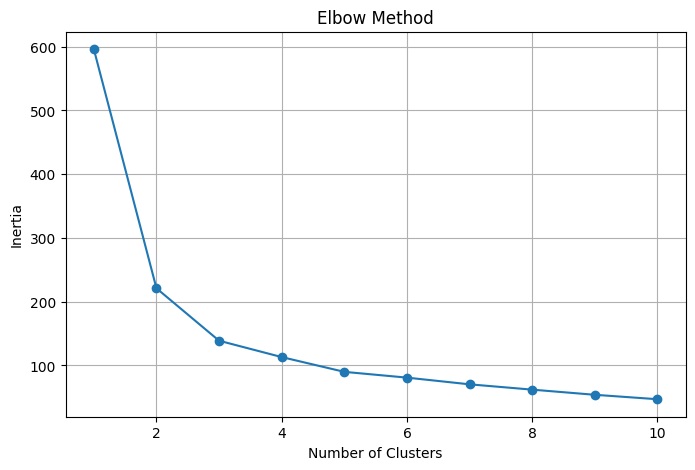

In [9]:
# Elbow Method

inertia = []

K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot the Elbow Curve

plt.figure(figsize=(8,5))

plt.plot(K, inertia, marker='o')

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("Inertia")

plt.grid(True)

plt.show()

In [10]:
# Train K-Means

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

clusters = kmeans.fit_predict(X_scaled)

df["KMeans_Cluster"] = clusters

print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species  KMeans_Cluster  
0        0               1  
1        0               1  
2        0               1  
3        0               1  
4        0               1  


In [11]:
# Evaluate K-Means

silhouette_kmeans = silhouette_score(X_scaled, clusters)

print("K-Means Silhouette Score:", round(silhouette_kmeans,3))

K-Means Silhouette Score: 0.461


## Dimensionality Reduction Using PCA

Principal Component Analysis (PCA) reduces the dataset to two dimensions while preserving most of the variation in the data. This makes it easier to visualize the clusters identified by K-Means.

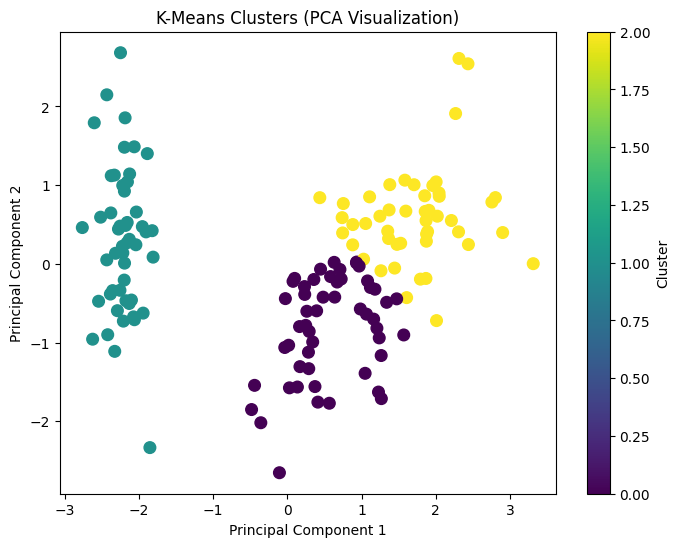

In [12]:
# PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=clusters,
    cmap='viridis',
    s=70
)

plt.title("K-Means Clusters (PCA Visualization)")

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.colorbar(label="Cluster")

plt.show()

## Hierarchical Clustering

Hierarchical clustering is another unsupervised learning technique that groups observations based on their similarity. Unlike K-Means, it does not require random initialization and produces a dendrogram that illustrates how clusters are formed.

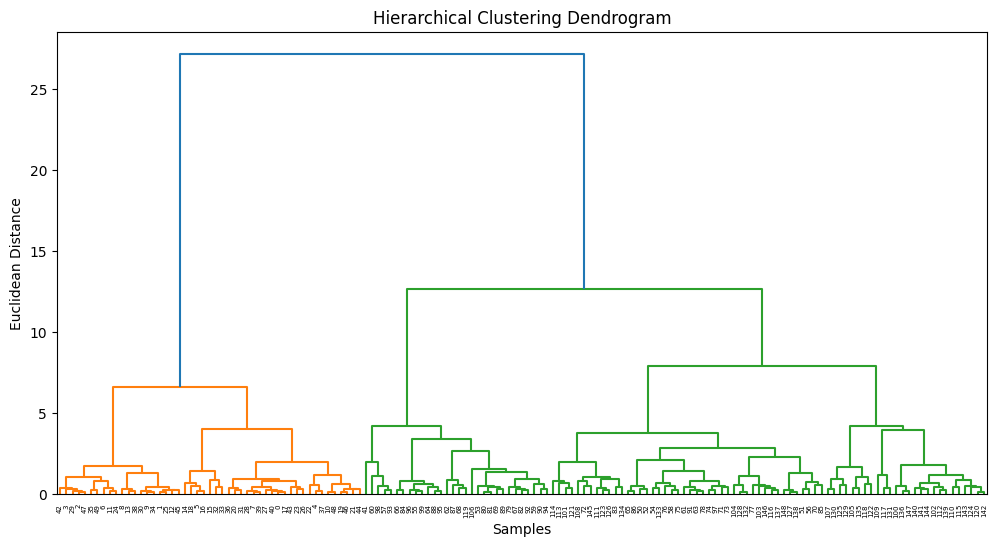

In [13]:
# Import linkage and dendrogram

from scipy.cluster.hierarchy import linkage, dendrogram

# Create linkage matrix

linked = linkage(X_scaled, method='ward')

# Plot dendrogram

plt.figure(figsize=(12,6))

dendrogram(linked)

plt.title("Hierarchical Clustering Dendrogram")

plt.xlabel("Samples")

plt.ylabel("Euclidean Distance")

plt.show()

In [14]:
# Hierarchical Clustering

hierarchical = AgglomerativeClustering(n_clusters=3)

hierarchical_clusters = hierarchical.fit_predict(X_scaled)

df["Hierarchical_Cluster"] = hierarchical_clusters

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,KMeans_Cluster,Hierarchical_Cluster
0,5.1,3.5,1.4,0.2,0,1,1
1,4.9,3.0,1.4,0.2,0,1,1
2,4.7,3.2,1.3,0.2,0,1,1
3,4.6,3.1,1.5,0.2,0,1,1
4,5.0,3.6,1.4,0.2,0,1,1


In [15]:
# Silhouette Score

silhouette_hierarchical = silhouette_score(
    X_scaled,
    hierarchical_clusters
)

print(
    "Hierarchical Clustering Silhouette Score:",
    round(silhouette_hierarchical,3)
)

Hierarchical Clustering Silhouette Score: 0.45


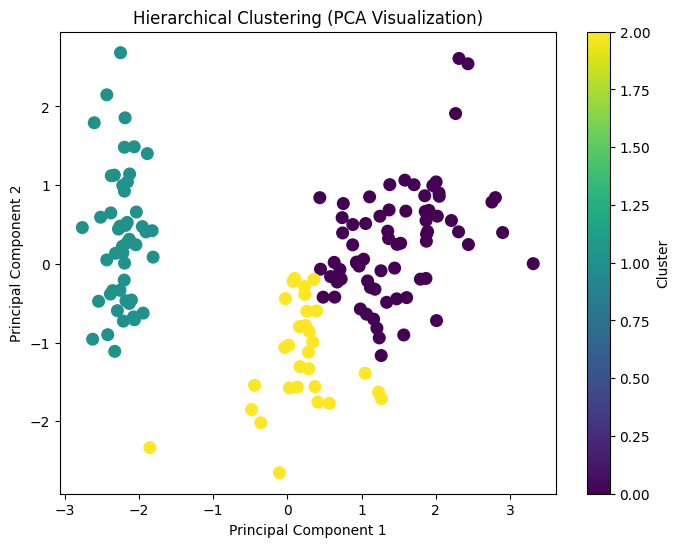

In [16]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=hierarchical_clusters,
    cmap='viridis',
    s=70
)

plt.title("Hierarchical Clustering (PCA Visualization)")

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.colorbar(label="Cluster")

plt.show()

## Model Evaluation

The clustering algorithms were evaluated using the Silhouette Score, which measures how well observations fit within their assigned clusters. Higher values indicate better cluster separation and cohesion.

The results showed that K-Means achieved a Silhouette Score of 0.461, while Hierarchical Clustering achieved a score of 0.450. Although both algorithms performed well, K-Means slightly outperformed Hierarchical Clustering, indicating that it produced better-defined clusters for the Iris dataset.

In [17]:
# Compare clustering models

comparison = pd.DataFrame({
    "Model": [
        "K-Means",
        "Hierarchical Clustering"
    ],
    "Silhouette Score": [
        round(silhouette_kmeans,3),
        round(silhouette_hierarchical,3)
    ]
})

comparison

,Model,Silhouette Score
0,K-Means,0.461
1,Hierarchical Clustering,0.450


## Deployment Strategy

The K-Means clustering model is recommended for deployment because it achieved the highest Silhouette Score. The trained model can be saved using Joblib or Pickle and integrated into a web application or analytics dashboard. New observations can be assigned to existing clusters to support data analysis and decision-making.

## Model Monitoring

After deployment, the clustering model should be monitored regularly to ensure that incoming data remains consistent with the original training data. Changes in data patterns may reduce clustering quality over time. Periodic retraining using updated data and continuous monitoring of cluster distributions and evaluation metrics are recommended to maintain model performance.

## Conclusion

This project demonstrated the application of unsupervised machine learning techniques using the Iris dataset. Data preprocessing, K-Means clustering, Hierarchical Clustering, and Principal Component Analysis (PCA) were successfully implemented. Both clustering algorithms performed well; however, K-Means achieved the highest Silhouette Score (0.461), making it the preferred model for this dataset. Overall, the project illustrates the effectiveness of clustering techniques in discovering natural groupings within unlabeled data.